In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel('/Users/daniyalrosli/zakat_project/Data Zakat.xlsx')

In [ ]:
#  data information

df.info()
df.describe()
df.isnull().sum()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  14 non-null     object
 1   Unnamed: 1  14 non-null     object
dtypes: object(2)
memory usage: 372.0+ bytes


,Unnamed: 0,Unnamed: 1
0,NaN,NaN
1,Daerah,Total Income
2,BB,215
3,BL,1084
4,KL,624


In [12]:
# Exploratory Data Analysis (EDA)

# Basic statistics
print("Basic Statistics:")
print("-----------------")
print("\nShape of dataset:", df.shape)
print("\nDataset Info:")
df.info()
print("\nDescriptive Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

# Income Analysis
print("\nIncome Analysis:")
print("-----------------")
print("\nMean Income:", df['Total_Income'].mean().round(2))
print("Median Income:", df['Total_Income'].median())
print("Standard Deviation:", df['Total_Income'].std().round(2))

# Remove Grand Total for accurate statistics
df_no_total = df[df['District'] != 'Grand Total']

# Statistical Analysis
print("\nDetailed Income Statistics (excluding Grand Total):")
print("------------------------------------------------")
print("\nMean Income:", df_no_total['Total_Income'].mean().round(2))
print("Median Income:", df_no_total['Total_Income'].median())
print("Standard Deviation:", df_no_total['Total_Income'].std().round(2))
print("\nSkewness:", stats.skew(df_no_total['Total_Income']).round(2))
print("Kurtosis:", stats.kurtosis(df_no_total['Total_Income']).round(2))

# District Analysis
print("\nDistrict Analysis:")
print("-----------------")
print("\nNumber of Districts:", len(df_no_total))
print("\nHighest Income District:", df_no_total.loc[df_no_total['Total_Income'].idxmax(), 'District'])
print("Lowest Income District:", df_no_total.loc[df_no_total['Total_Income'].idxmin(), 'District'])

# Income Categories
income_categories = pd.cut(df_no_total['Total_Income'], 
                         bins=[0, 300, 600, 900, float('inf')],
                         labels=['Very Low', 'Low', 'Medium', 'High'])
print("\nIncome Categories Distribution:")
print(income_categories.value_counts().sort_index())

Basic Statistics:
-----------------

Shape of dataset: (13, 2)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 2 to 14
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   District      13 non-null     object
 1   Total_Income  13 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 340.0+ bytes

Descriptive Statistics:
       Total_Income
count     13.000000
mean    1208.307692
std     2047.154952
min      111.000000
25%      313.000000
50%      624.000000
75%     1084.000000
max     7854.000000

Missing Values:
District        0
Total_Income    0
dtype: int64

Income Analysis:
-----------------

Mean Income: 1208.31
Median Income: 624.0
Standard Deviation: 2047.15

Detailed Income Statistics (excluding Grand Total):
------------------------------------------------

Mean Income: 654.5
Median Income: 581.5
Standard Deviation: 471.41

Skewness: 0.9
Kurtosis: -0.21

District Analysis

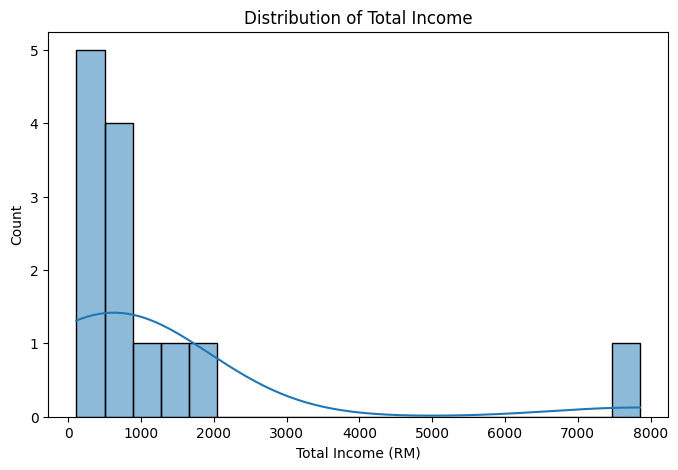

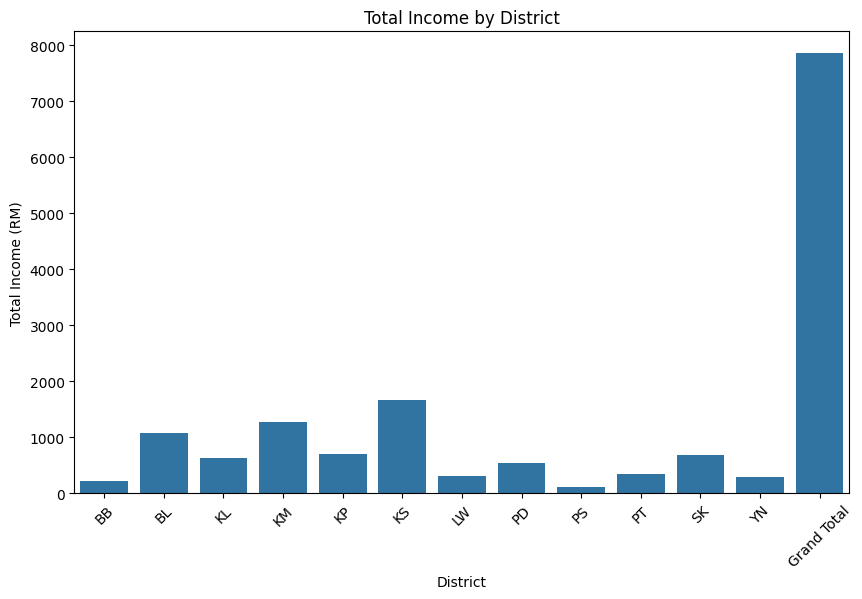

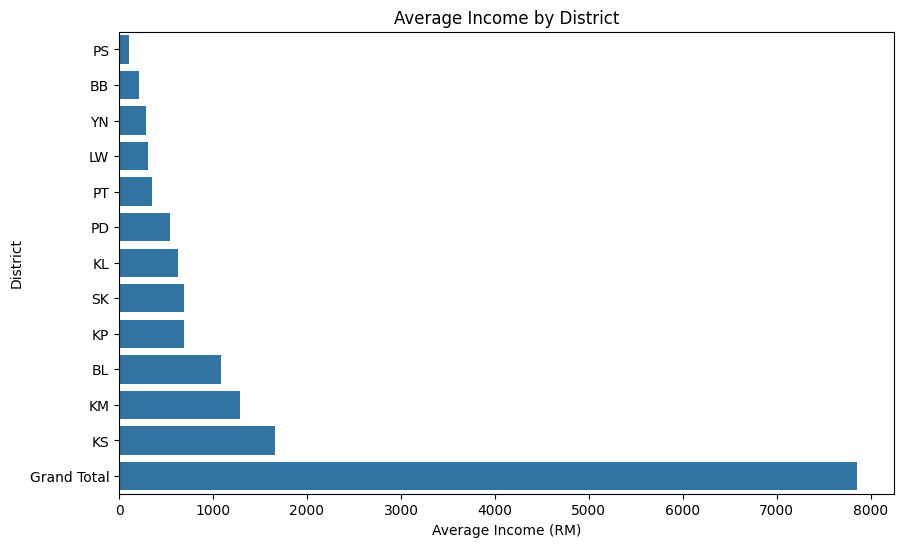

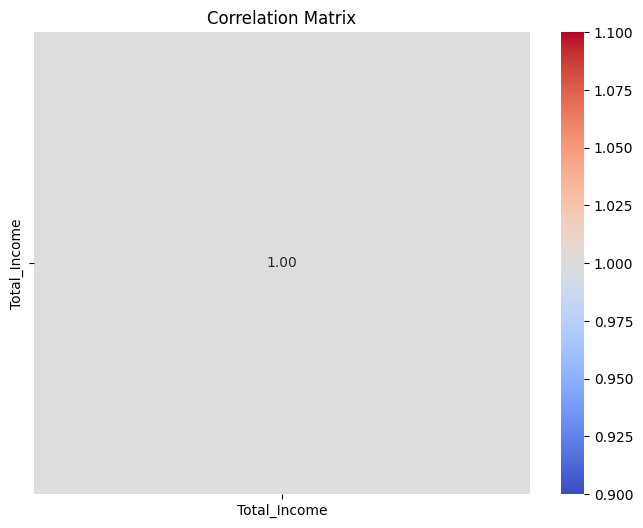

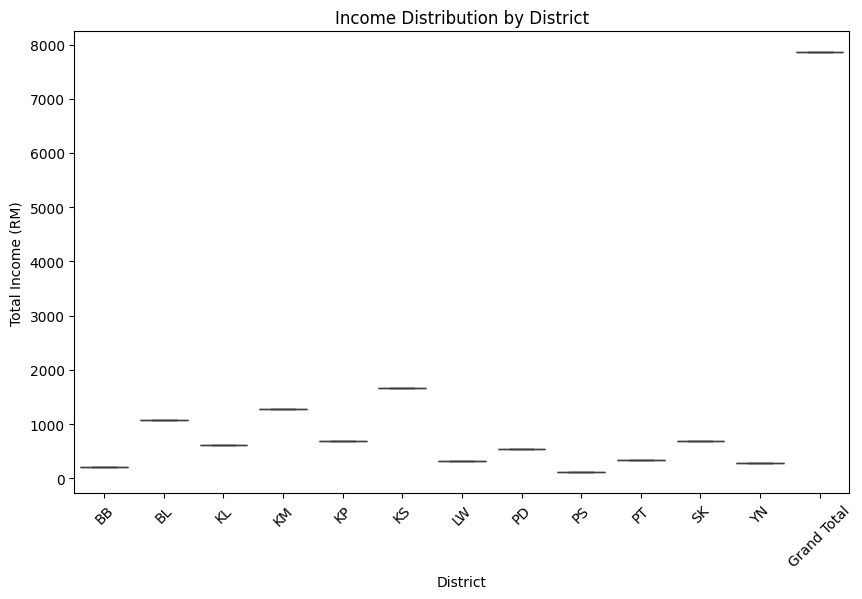

In [10]:
# data visualization
# -------------------------------
# 📊 DATA VISUALIZATION
# -------------------------------

# Distribution of Total Income
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Total_Income", bins=20, kde=True)
plt.title("Distribution of Total Income")
plt.xlabel("Total Income (RM)")
plt.show()

# Total Income by District
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="District", y="Total_Income")
plt.xticks(rotation=45)
plt.title("Total Income by District")
plt.xlabel("District")
plt.ylabel("Total Income (RM)")
plt.show()

# District-level Income Distribution
plt.figure(figsize=(10,6))
district_income = df.groupby("District")["Total_Income"].mean().sort_values()
sns.barplot(x=district_income.values, y=district_income.index)
plt.title("Average Income by District")
plt.xlabel("Average Income (RM)")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Distribution of Total Income by District
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="District", y="Total_Income")
plt.xticks(rotation=45)
plt.title("Income Distribution by District")
plt.xlabel("District")
plt.ylabel("Total Income (RM)")
plt.show()




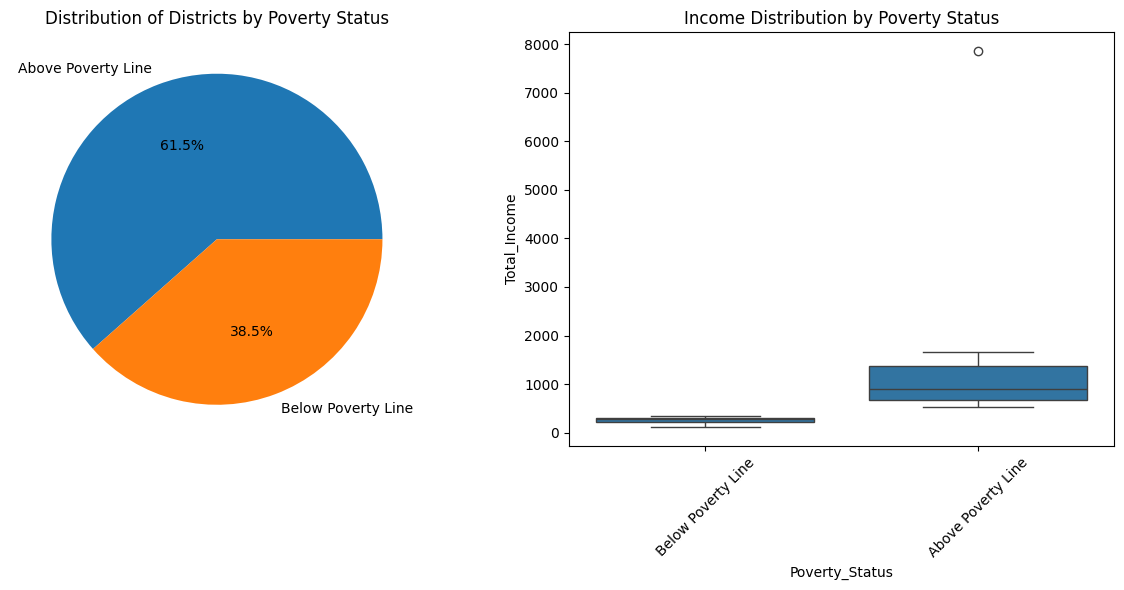


Poverty Analysis Summary:
                   District Total_Income           
                      count         mean  min   max
Poverty_Status                                     
Above Poverty Line        8      1803.88  539  7854
Below Poverty Line        5       255.40  111   348

Districts Below Poverty Line:
['BB', 'LW', 'PS', 'PT', 'YN']

Districts Above Poverty Line:
['BL', 'KL', 'KM', 'KP', 'KS', 'PD', 'SK', 'Grand Total']


In [11]:
# Define poverty thresholds (example thresholds - adjust as needed)
POVERTY_LINE = 500  # Example poverty line threshold

# Create poverty status analysis
poverty_analysis = df.copy()
poverty_analysis['Poverty_Status'] = poverty_analysis['Total_Income'].apply(
    lambda x: 'Below Poverty Line' if x < POVERTY_LINE else 'Above Poverty Line'
)

# Calculate summary statistics
poverty_summary = poverty_analysis.groupby('Poverty_Status').agg({
    'District': 'count',
    'Total_Income': ['mean', 'min', 'max']
}).round(2)

# Visualization of poverty status
plt.figure(figsize=(12, 6))

# Plot 1: Districts by Poverty Status
plt.subplot(1, 2, 1)
poverty_counts = poverty_analysis['Poverty_Status'].value_counts()
plt.pie(poverty_counts, labels=poverty_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Districts by Poverty Status')

# Plot 2: Income Distribution by Poverty Status
plt.subplot(1, 2, 2)
sns.boxplot(data=poverty_analysis, x='Poverty_Status', y='Total_Income')
plt.title('Income Distribution by Poverty Status')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nPoverty Analysis Summary:")
print("========================")
print(poverty_summary)

# List districts in each category
print("\nDistricts Below Poverty Line:")
print("===========================")
print(poverty_analysis[poverty_analysis['Poverty_Status'] == 'Below Poverty Line']['District'].tolist())

print("\nDistricts Above Poverty Line:")
print("===========================")
print(poverty_analysis[poverty_analysis['Poverty_Status'] == 'Above Poverty Line']['District'].tolist())

In [ ]:
#create target variable for classification model